# Time Series Analysis (TSA) & ARIMA: Afghanistan (Admin1)

Questo notebook analizza l'andamento temporale dell'indice dei prezzi alimentari WFP (`wfp_price_mean`) a livello provinciale (Admin1) in Afghanistan.
L'obiettivo è esplorare la serie storica, valutarne la stazionarietà e provare ad addestrare un modello **ARIMA/SARIMAX** per la previsione dei prezzi.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistiche e Time Series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Setup plot
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

In [2]:
# Percorso del dataset aggregato
data_path = "../data/tmp/wfp_monthly_adm1_index.parquet"

if not os.path.exists(data_path):
    raise FileNotFoundError(f"File non trovato a: {data_path}. Eseguire prima generate_aggregations.py.")

df = pd.read_parquet(data_path, engine="pyarrow")
df['date'] = pd.to_datetime(df['date'])

# Filtro per l'Afghanistan
df_afg = df[df['ISO3'] == 'AFG'].copy()
print(f"Numero totale di righe per AFG: {len(df_afg)}")
print(f"Province disponibili in AFG: {df_afg['adm1_name'].nunique()}")

Numero totale di righe per AFG: 7888
Province disponibili in AFG: 34


### Selezione della Provincia
Selezioniamo come esempio la provincia di **Kabul** (o un'altra a scelta) e impostiamo la data come indice della serie storica.

In [3]:
provincia = 'Kabul'
df_prov = df_afg[df_afg['adm1_name'] == provincia].copy()

# Impostiamo la data come indice e ordiniamo temporalmente
df_prov = df_prov.set_index('date').sort_index()

# Assicuriamoci che la frequenza dell'indice sia impostata a Mensile ('MS' per inizio mese o 'ME' per fine mese)
# I nostri dati hanno date tipo YYYY-MM-01, quindi usiamo 'MS' (Month Start)
df_prov = df_prov.asfreq('MS')

print(f"Serie storica per {provincia} - Da: {df_prov.index.min()} A: {df_prov.index.max()}")
print(f"Valori nulli in wfp_price_mean: {df_prov['wfp_price_mean'].isna().sum()}")

# Gestione di eventuali valori nulli tramite interpolazione lineare
if df_prov['wfp_price_mean'].isna().any():
    print("Trovati valori nulli, applicazione dell'interpolazione lineare...")
    df_prov['wfp_price_mean'] = df_prov['wfp_price_mean'].interpolate(method='linear')

ts = df_prov['wfp_price_mean']

Serie storica per Kabul - Da: 2007-01-01 00:00:00 A: 2026-04-01 00:00:00
Valori nulli in wfp_price_mean: 0


### 1. Visualizzazione Grafica della Serie Storica

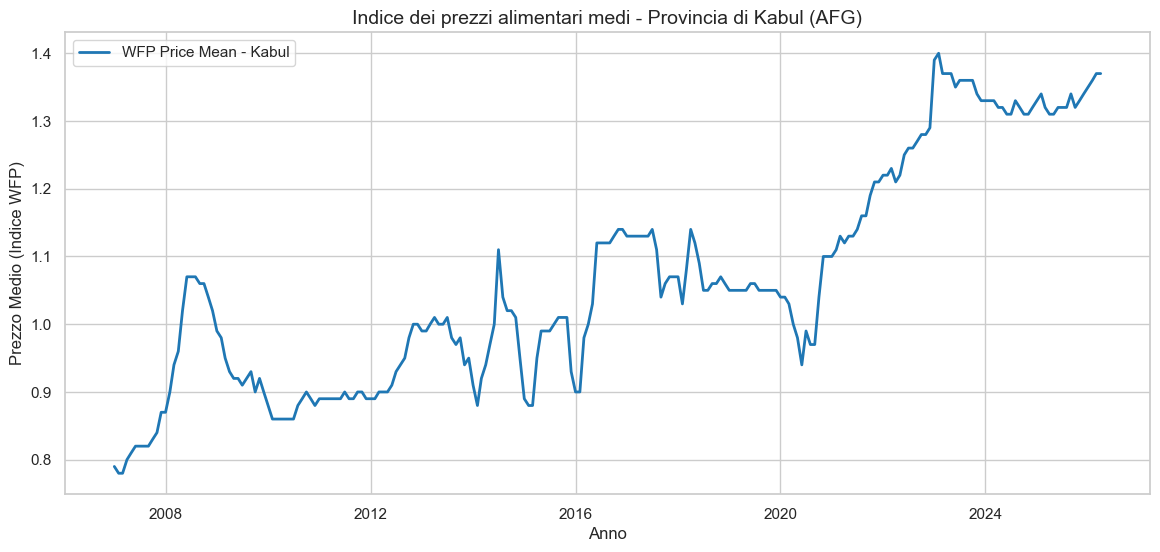

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(ts, label=f"WFP Price Mean - {provincia}", color='#1f77b4', linewidth=2)
plt.title(f"Indice dei prezzi alimentari medi - Provincia di {provincia} (AFG)", fontsize=14)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Prezzo Medio (Indice WFP)", fontsize=12)
plt.legend(loc="upper left")
plt.show()

### 2. Analisi di Stazionarietà (Augmented Dickey-Fuller Test)
I modelli ARIMA richiedono una serie storica stazionaria (media, varianza e autocovarianza costanti nel tempo).
Visualizziamo la media/deviazione standard mobile (rolling stats) ed eseguiamo il test ADF.

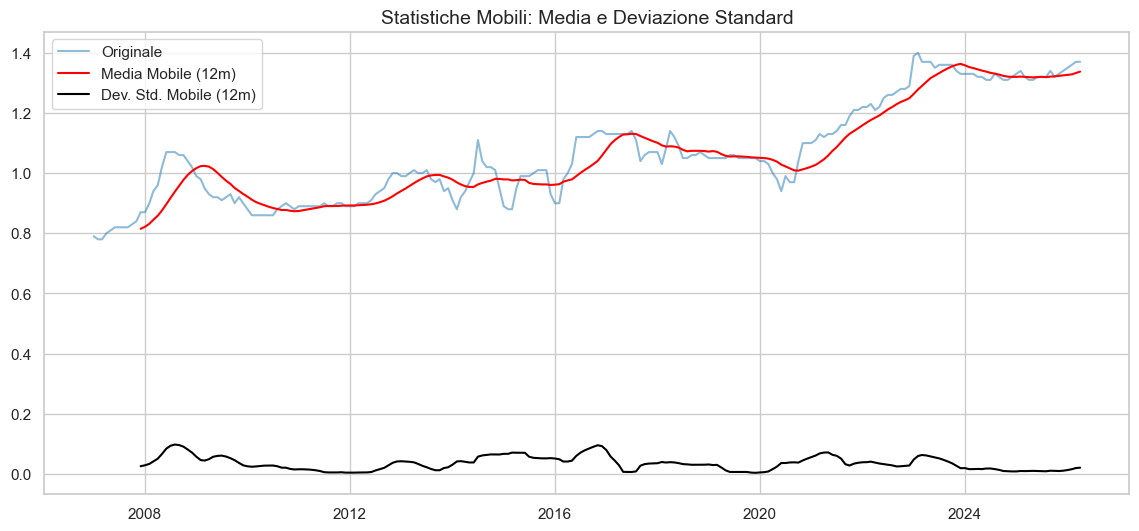

Risultati dell'Augmented Dickey-Fuller Test:
Test Statistic                  -1.343853
p-value                          0.608878
#Lags Used                       1.000000
Number of Observations Used    230.000000
Critical Value (1%)             -3.459106
Critical Value (5%)             -2.874190
Critical Value (10%)            -2.573512
dtype: float64

--> La serie NON è stazionaria (p-value >= 0.05). Sarà necessario applicare il differenziamento.


In [5]:
def check_stationarity(timeseries, window=12):
    # Rolling statistics
    rolmean = timeseries.rolling(window=window).mean()
    rolstd = timeseries.rolling(window=window).std()

    # Plot
    plt.figure(figsize=(14, 6))
    plt.plot(timeseries, color='#1f77b4', label='Originale', alpha=0.5)
    plt.plot(rolmean, color='red', label=f'Media Mobile ({window}m)')
    plt.plot(rolstd, color='black', label=f'Dev. Std. Mobile ({window}m)')
    plt.legend(loc='best')
    plt.title('Statistiche Mobili: Media e Deviazione Standard', fontsize=14)
    plt.show()

    # ADF Test
    print('Risultati dell\'Augmented Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    print(dfoutput)
    
    if dfoutput['p-value'] < 0.05:
        print("\n--> La serie è STAZIONARIA (p-value < 0.05)")
    else:
        print("\n--> La serie NON è stazionaria (p-value >= 0.05). Sarà necessario applicare il differenziamento.")

check_stationarity(ts)

#### Differenziamento per rendere la serie stazionaria
Se il p-value del test ADF è superiore a 0.05, applichiamo un differenziamento del primo ordine ($d=1$) e rivalutiamo.

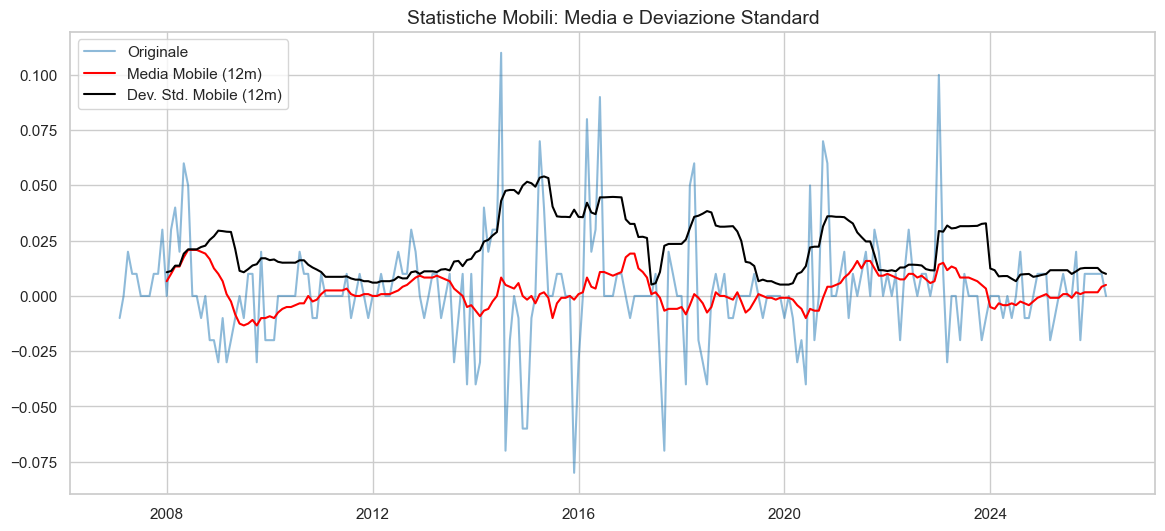

Risultati dell'Augmented Dickey-Fuller Test:
Test Statistic                -1.208761e+01
p-value                        2.159313e-22
#Lags Used                     0.000000e+00
Number of Observations Used    2.300000e+02
Critical Value (1%)           -3.459106e+00
Critical Value (5%)           -2.874190e+00
Critical Value (10%)          -2.573512e+00
dtype: float64

--> La serie è STAZIONARIA (p-value < 0.05)


In [6]:
ts_diff = ts.diff().dropna()
check_stationarity(ts_diff)

### 3. Decomposizione della Serie Storica
Decomponiamo la serie in Trend, Stagionalità e Componente Residua per osservare la struttura sottostante.

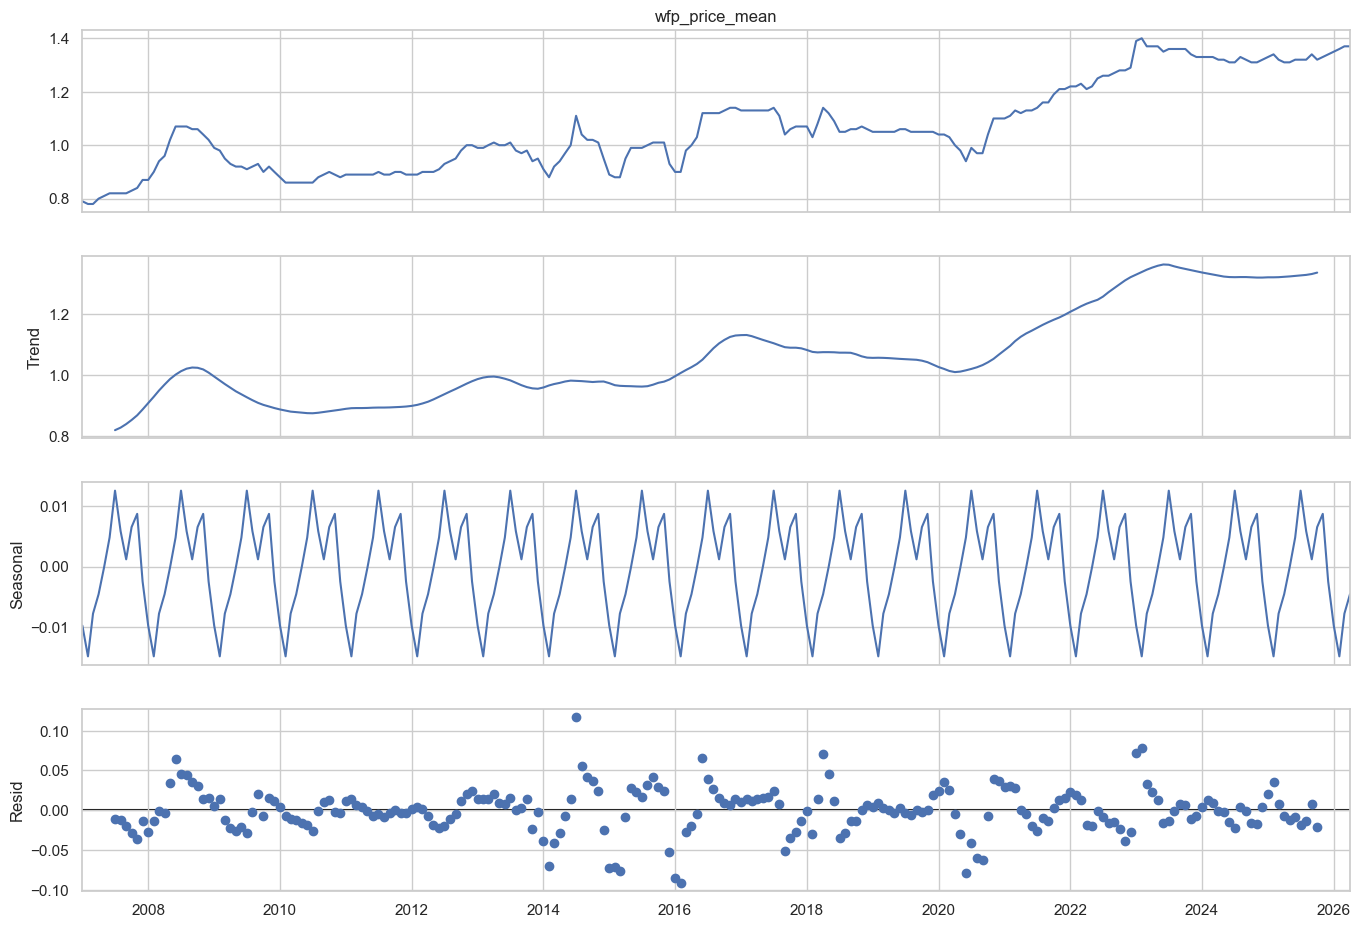

In [7]:
decomposition = seasonal_decompose(ts, model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

### 4. Grafici ACF (Autocorrelation) e PACF (Partial Autocorrelation)
Questi grafici aiutano ad identificarne i parametri autoregressivi ($p$) e a media mobile ($q$) del modello ARIMA sulla serie differenziata.

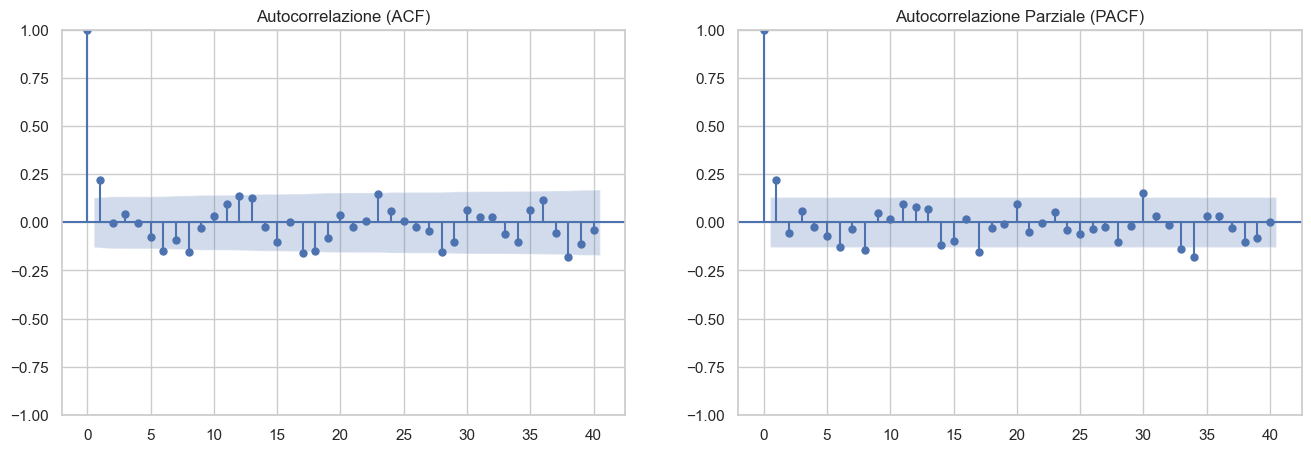

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(ts_diff, lags=40, ax=axes[0], title='Autocorrelazione (ACF)')
plot_pacf(ts_diff, lags=40, ax=axes[1], title='Autocorrelazione Parziale (PACF)')
plt.show()

### 5. Modellazione ARIMA e SARIMAX
Dividiamo la serie storica in:
- **Train Set**: dati storici fino a 12 mesi fa.
- **Test Set**: gli ultimi 12 mesi della serie.

Dopodiché proveremo a calibrare:
1. Un modello **ARIMA(p, d, q)** classico (es. `ARIMA(1, 1, 1)`).
2. Un modello **SARIMAX(p, d, q)x(P, D, Q, s)** per catturare la stagionalità annuale (`s=12`).

In [9]:
# Dividiamo in Train (fino a 12 mesi fa) e Test (ultimi 12 mesi)
train = ts.iloc[:-12]
test = ts.iloc[-12:]

print(f"Train size: {len(train)} (da {train.index.min()} a {train.index.max()})")
print(f"Test size: {len(test)} (da {test.index.min()} a {test.index.max()})")

Train size: 220 (da 2007-01-01 00:00:00 a 2025-04-01 00:00:00)
Test size: 12 (da 2025-05-01 00:00:00 a 2026-04-01 00:00:00)


In [10]:
print("--- Adattamento modello ARIMA(1, 1, 1) ---")
arima_model = ARIMA(train, order=(1, 1, 1))
arima_results = arima_model.fit()
print(arima_results.summary())

--- Adattamento modello ARIMA(1, 1, 1) ---
                               SARIMAX Results                                
Dep. Variable:         wfp_price_mean   No. Observations:                  220
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 505.126
Date:                Sat, 27 Jun 2026   AIC                          -1004.253
Time:                        11:54:24   BIC                           -994.085
Sample:                    01-01-2007   HQIC                         -1000.146
                         - 04-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0116      0.261     -0.044      0.965      -0.523       0.500
ma.L1          0.2623      0.264      0.993      0.321      -0.255       0.780
sigma2   

In [11]:
print("--- Adattamento modello SARIMAX(1, 1, 1)x(1, 1, 1, 12) ---")
sarimax_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
sarimax_results = sarimax_model.fit(disp=False)
print(sarimax_results.summary())

--- Adattamento modello SARIMAX(1, 1, 1)x(1, 1, 1, 12) ---
                                     SARIMAX Results                                      
Dep. Variable:                     wfp_price_mean   No. Observations:                  220
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 428.166
Date:                            Sat, 27 Jun 2026   AIC                           -846.332
Time:                                    11:54:24   BIC                           -830.019
Sample:                                01-01-2007   HQIC                          -839.726
                                     - 04-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2893      0.247     -1.171      0.242 

### 6. Diagnostica del Modello
Controlliamo i residui per verificare se assomigliano a rumore bianco (assenza di autocorrelazione residua e distribuzione normale).

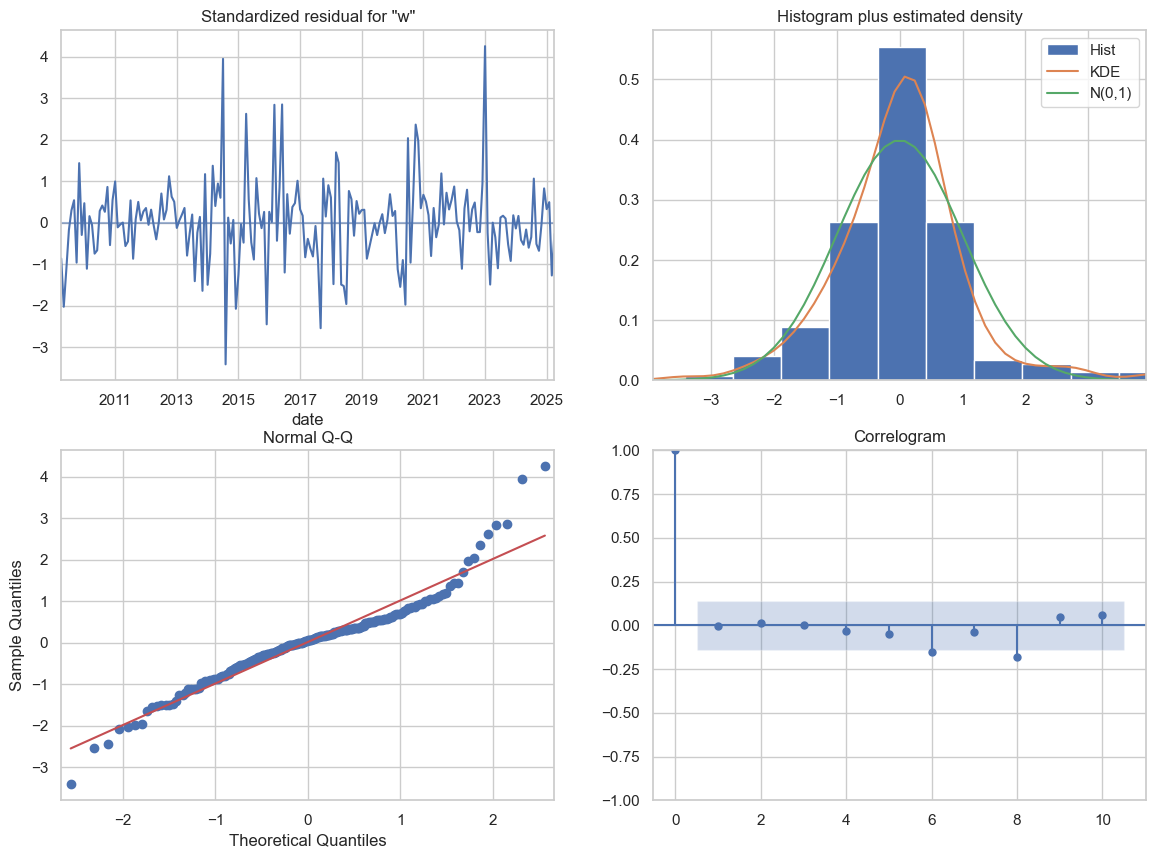

In [12]:
sarimax_results.plot_diagnostics(figsize=(14, 10))
plt.show()

### 7. Previsione (Forecasting)
Effettuiamo la previsione sugli ultimi 12 mesi (Test set) e proiettiamoci nel futuro (ulteriori 12 mesi), mostrando l'intervallo di confidenza al 95%.

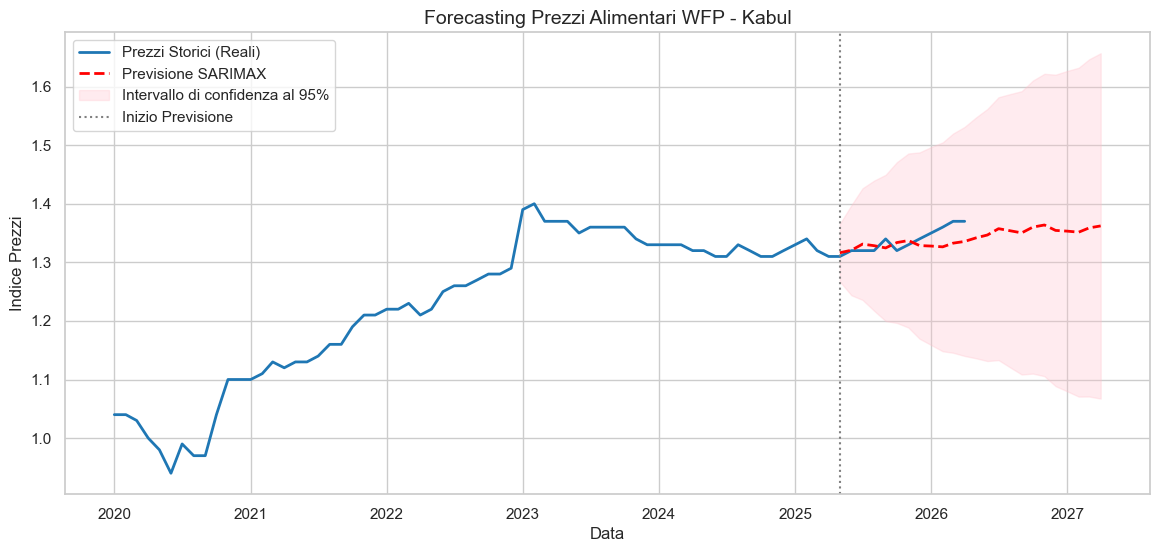

In [13]:
# Previsione sul periodo del Test set + 12 mesi futuri (totale 24 mesi)
forecast_steps = 24
forecast_res = sarimax_results.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=test.index[0], periods=forecast_steps, freq='MS')

forecast_mean = forecast_res.predicted_mean
forecast_mean.index = forecast_index

confidence_intervals = forecast_res.conf_int(alpha=0.05)
confidence_intervals.index = forecast_index

# Plot dei risultati
plt.figure(figsize=(14, 6))
plt.plot(ts.loc['2020-01-01':], label='Prezzi Storici (Reali)', color='#1f77b4', linewidth=2)
plt.plot(forecast_mean, label='Previsione SARIMAX', color='red', linestyle='--', linewidth=2)
plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    color='pink',
    alpha=0.3,
    label='Intervallo di confidenza al 95%'
)
plt.axvline(x=test.index[0], color='gray', linestyle=':', label='Inizio Previsione')
plt.title(f"Forecasting Prezzi Alimentari WFP - {provincia}", fontsize=14)
plt.xlabel("Data", fontsize=12)
plt.ylabel("Indice Prezzi", fontsize=12)
plt.legend(loc='upper left')
plt.show()